## MSD from LAMMPS fix

Let's use this to find the terminal relaxation time.

Each timestep is 0.005 $\tau$ and each snapshot is 10000 apart from each other.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

filename = "data/msd/prodmsd_chainlength_30_N_beads_24000_gaussA_20_r0_0.35_gaussB_10_seed_12345.dat"

times = []
msd = []
msd_calculated = []
msd_std = []
counts = []

# columns are chunk_id, dx^2, dy^2, dz^2, RMSD^2
with open(filename, 'r') as f:
    while True:
        line = f.readline()
        if not line:
            break
        if line.startswith("#"):
            # print("skipping header line")
            continue
        # print("processing line:", line)
        current_timestep, num_entries = line.strip().split() # get the timestep from the next line after the header
        # print(f"Current timestep: {current_timestep}, Number of entries: {num_entries}")
        dx_values = np.zeros(int(num_entries))
        dy_values = np.zeros(int(num_entries))
        dz_values = np.zeros(int(num_entries))
        RMSD_values = np.zeros(int(num_entries))
        for i in range(int(num_entries)):
            _, dx_values[i], dy_values[i], dz_values[i], RMSD_values[i] = next(f).strip().split() # read the RMSD value from the 5th column of each line
        rms_calculated = np.mean(dx_values + dy_values + dz_values)

        # average over all chains for this timestep
        msd_calculated.append(np.mean(rms_calculated))
        times.append(current_timestep)
        msd.append(np.mean(RMSD_values))
        msd_std.append(np.std(RMSD_values))
        counts.append(int(num_entries))

In [4]:
times = np.array(times, dtype=float)
times = times - times[0] # shift time to start from 0
times = times * 0.005
msd = np.array(msd, dtype=float)
msd_calculated = np.array(msd_calculated, dtype=float)
msd_std = np.array(msd_std, dtype=float)
counts = np.array(counts, dtype=int)
# print(times)

In [5]:
msd_file = "data/msd/msd.csv"
df = pd.read_csv(msd_file, header=None, names=["time", "msd"])


13703 13703


/tmp/ipykernel_65430/688646681.py:3: RuntimeWarning: invalid value encountered in divide
  plt.loglog(times, msd/np.sqrt(times), label="MSD from LAMMPS")


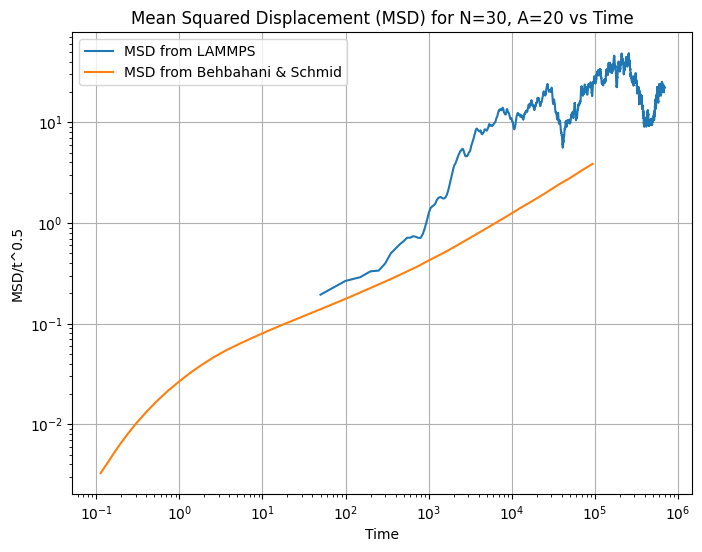

In [6]:
print(len(times), len(msd))
figure = plt.figure(figsize=(8, 6))
plt.loglog(times, msd/np.sqrt(times), label="MSD from LAMMPS")
plt.loglog(df["time"], df["msd"], label="MSD from Behbahani & Schmid")
# plt.plot(times, msd_calculated, label="MSD calculated from dx, dy, dz")
plt.title("Mean Squared Displacement (MSD) for N=30, A=20 vs Time")
plt.xlabel("Time")
plt.ylabel("MSD/t^0.5")
plt.grid()
plt.legend()
plt.show()

## Calculation based on Behbahani & Schmid data

The data from Figure 2d) is

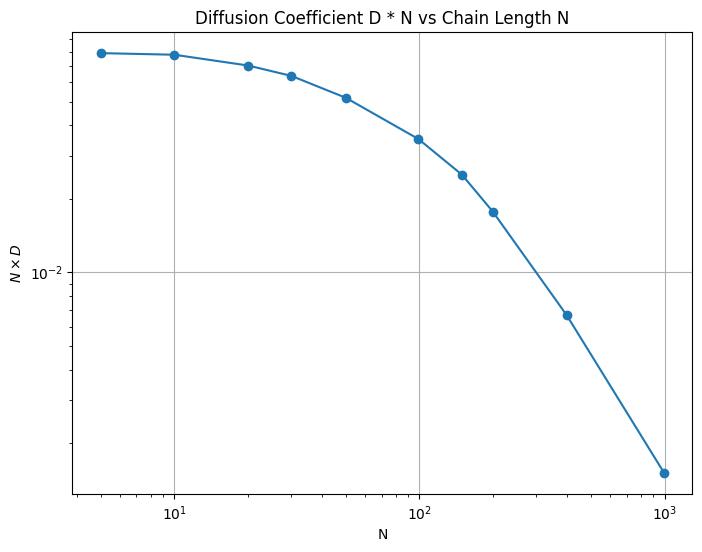

In [7]:
file = "data/msd/NxD.csv"

df = pd.read_csv(file, header=None, names=["N", "D*N"])
df["N"] = df["N"].round().astype(int)  # round N to nearest integer
plt.figure(figsize=(8, 6))
plt.loglog(df["N"], df["D*N"], marker='o')
plt.title("Diffusion Coefficient D * N vs Chain Length N")
plt.xlabel(r"N")
plt.ylabel(r"$N \times D$")
plt.grid()
plt.show()

In [8]:
DN_30 = df["D*N"][df["N"] == 30].values[0]
print(f"D*N for N=30: {DN_30}")

D*N for N=30: 0.06364


The relation for Rouse time we can use is

$$
D N = \frac{kT}\zeta
$$
$$
\tau_R = \frac{\zeta b^2 N^2}{ 3 \pi^2 kT}
$$
$$
\tau_R = \frac{b^2 N^2}{ 3 \pi^2 DN}
$$

In [9]:
b = 0.97
N = 30
DN = DN_30

tau_rouse = b**2 * N**2 / (3 * np.pi**2 * DN)
print(f"Rouse relaxation time for N=30: {tau_rouse:.2f} time units")

Rouse relaxation time for N=30: 449.40 time units


In [10]:
timesteps_rouse = tau_rouse/0.005
print(f"Rouse relaxation time in timesteps: {timesteps_rouse:.0f} timesteps")

Rouse relaxation time in timesteps: 89880 timesteps


## Average bond lifetime + bonding rate from averaging lifetime

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

f = "data/patches/0.7prodpatch_chainlength_30_patchspacing_5_N_beads_24000_gaussA_60_r0_0.25_gaussB_10_seed_12345.bin.txt"

N_patches = 4000
frame = 11

with open(f, "r") as file:
    for i in range((frame - 1) * (9 + N_patches) + 1):
        line = file.readline()
    # for i in range(9):
    print("Timestep:", file.readline())

df = pd.read_csv(f, skiprows=frame*9+(frame - 1) * N_patches, sep=' ', nrows=N_patches, header=None, names=["id", "mol", "x", "y", "z", "patch_coord", "patch_cluster"])
df.sort_values(by=["patch_coord", "id"], ascending=True, inplace=True)
print(df[df["patch_coord"] == 2])
print(df[df["patch_cluster"] == 8575])

Timestep: 100

Empty DataFrame
Columns: [id, mol, x, y, z, patch_coord, patch_cluster]
Index: []
        id  mol        x        y        z  patch_coord  patch_cluster
1489  8575  245  28.2518  3.62236  30.2707            0           8575


3891
3891
0
109


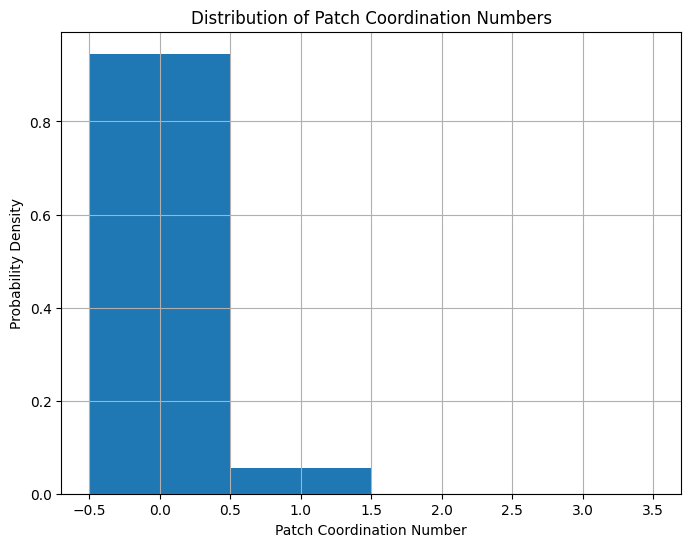

In [114]:
patch_cluster_list = np.unique(df["patch_cluster"].values)
print(len(patch_cluster_list))
cluster_size_list = np.zeros(len(patch_cluster_list))
print(len(cluster_size_list))


for i, patch_cluster in enumerate(patch_cluster_list):
    this_patch = df[df["patch_cluster"] == patch_cluster]
    # print("Patch id:", patch_cluster)
    # print(this_patch)
    cluster_size_list[i] = np.max(this_patch[["patch_coord"]].values)
    # print(f"Cluster {patch_cluster} has size {cluster_size_list[i]}")


# percentage of bonds with 3 patches
num_3_patch_bonds = np.sum(cluster_size_list == 2)
print(num_3_patch_bonds)
total_bonds = np.sum(cluster_size_list == 2) + np.sum(cluster_size_list == 1) # only consider bonds with at least 1 patch
print(total_bonds)
# percentage_3_patch_bonds = (num_3_patch_bonds / total_bonds) * 100
# print(f"Percentage of bonds with 3 patches: {percentage_3_patch_bonds:.2f}%")

# histogram of patch_coord
plt.figure(figsize=(8, 6))
plt.hist(df["patch_coord"], bins=np.arange(-0.5, 4.5, 1), density=True)
plt.title("Distribution of Patch Coordination Numbers")
plt.xlabel("Patch Coordination Number")
plt.ylabel("Probability Density")
plt.grid()
plt.show()  

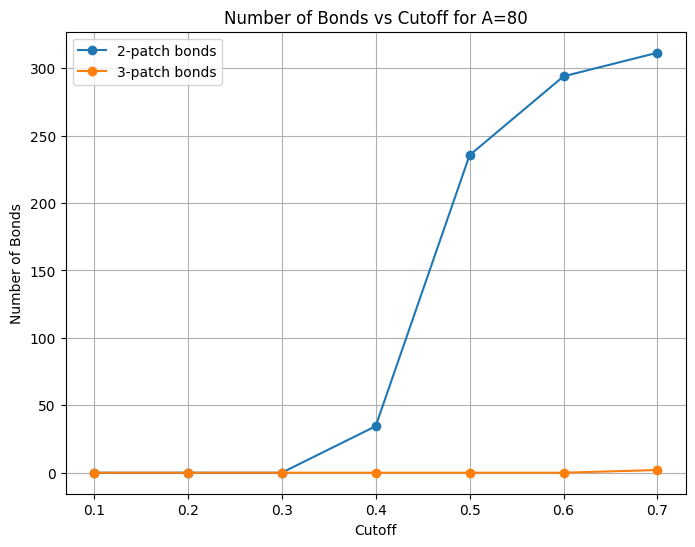

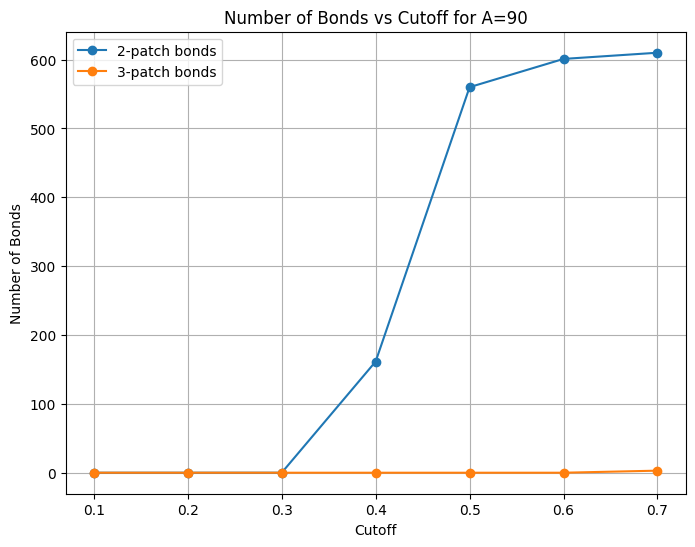

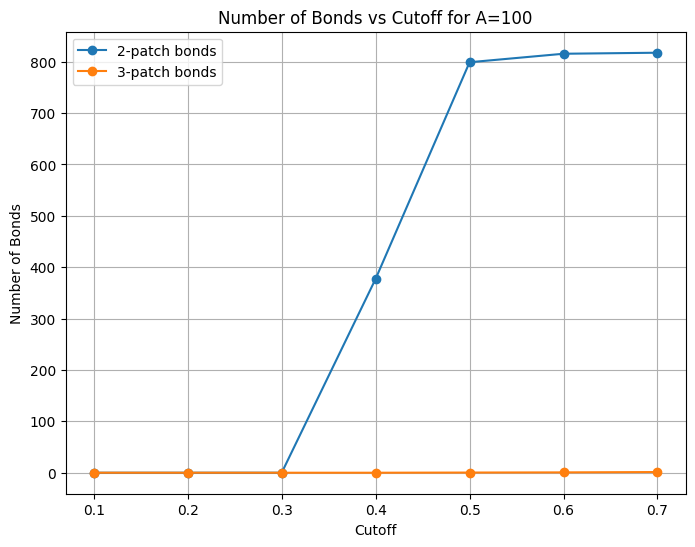

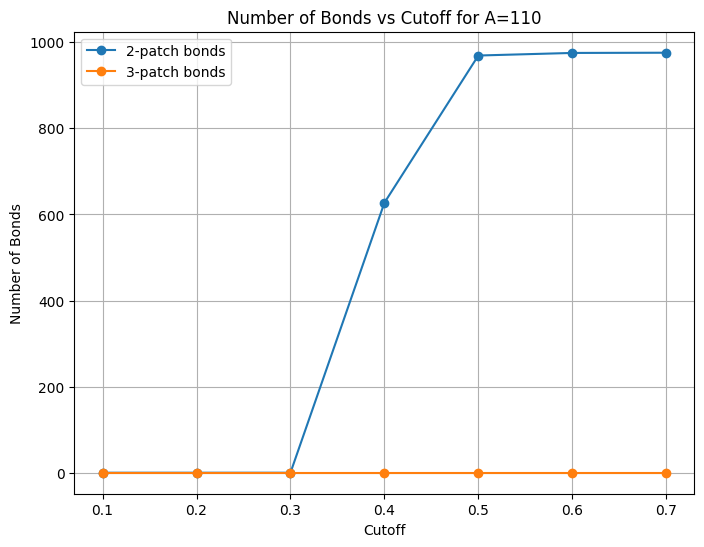

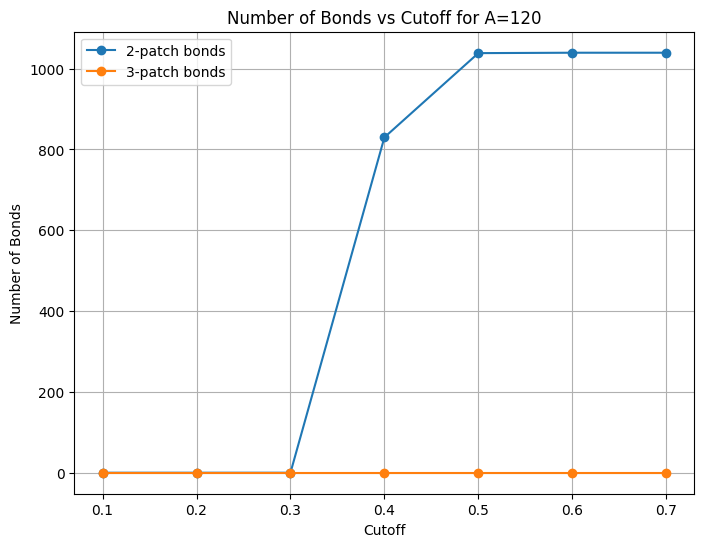

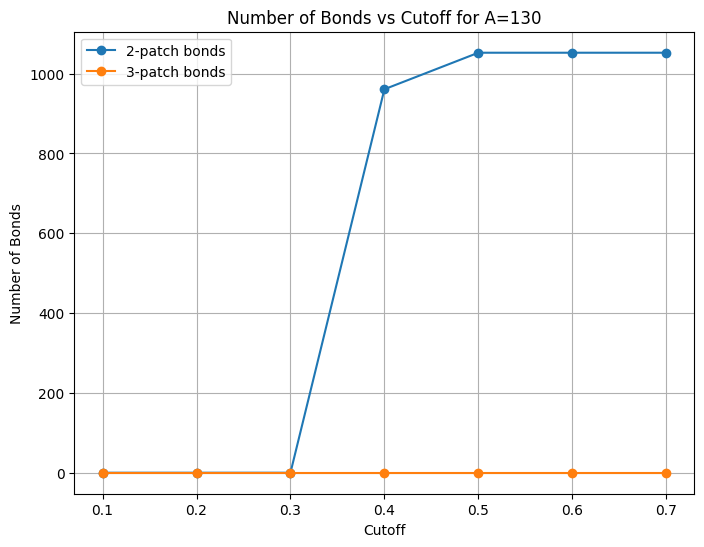

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


for A in [80, 90, 100, 110, 120, 130]:
    two_patch_bond_list = []
    three_patch_bond_list = []
    for cutoff in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
        filename = f"data/patches/{cutoff}prodpatch_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
        N_patches = 4000
        frame = 11

        # with open(filename, "r") as file:
        #     for i in range((frame - 1) * (9 + N_patches) + 1):
        #         line = file.readline()
        #     print("Timestep:", file.readline())

        df = pd.read_csv(filename, skiprows=frame*9+(frame - 1) * N_patches, sep=' ', nrows=N_patches, header=None, names=["id", "mol", "x", "y", "z", "patch_coord", "patch_cluster"])
        df.sort_values(by=["patch_coord", "id"], ascending=True, inplace=True)

        patch_cluster_list = np.unique(df["patch_cluster"].values)
        cluster_size_list = np.zeros(len(patch_cluster_list))

        for i, patch_cluster in enumerate(patch_cluster_list):
            this_patch = df[df["patch_cluster"] == patch_cluster]
            cluster_size_list[i] = np.max(this_patch[["patch_coord"]].values) + 1

        two_patch_bond_list.append(np.sum(cluster_size_list == 2)/2)
        three_patch_bond_list.append(np.sum(cluster_size_list == 3)/3)
    
    figure = plt.figure(figsize=(8, 6))
    plt.plot([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7], two_patch_bond_list, marker='o', label="2-patch bonds")
    plt.plot([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7], three_patch_bond_list, marker='o', label="3-patch bonds")
    plt.title(f"Number of Bonds vs Cutoff for A={A}")
    plt.xlabel("Cutoff")
    plt.ylabel("Number of Bonds")
    plt.grid()
    plt.legend()
    plt.show()

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# lifetime object:
#   - bonded_pair: (id1, id2)
#   - start_time: timestep when bond is formed
#   - end_time: timestep when bond breaks
#   - lifetime: end_time - start_time

# Read frame
# Filter only consider bonds with at least 1 patch
# sort by patch_cluster (get bonded pairs)
# Create broken flag list for all current bonded pairs
# if already existing in bonded pairs, set flag to false
# if not existing, add to bonded pairs and start counting lifetime until it breaks (patch_coord goes to 0)
# all pairs that have broken flag true, set end_time to current timestep, calculate lifetime, and remove from bonded pairs
"""
Process lifetimes from clustering data file. Each frame of the file contains the following sections:
- "ITEM: TIMESTEP" followed by the timestep on the next line
- "ITEM: NUMBER OF ATOMS" followed by the number of entries on the next line
- "ITEM: ATOMS" followed by the data lines for each entry, with 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster

The bonded_pairs list is a dictionary where the key is a tuple of (id1, id2) with id1 < id2 to avoid duplicates, and the value is the 
start_time of the bond. 

The bond_lifetimes list is a list of tuples (id1, id2, start_time, end_time, lifetime) for each bonded pair that has broken.

If there are any bonded_pairs that have not broken by the end of the dump, we ignore them and do not record a lifetime for them.

All times for breaking/creating are considered on the timestep we note them, so we should on average get the right time 
(i.e. both events are noted AFTER they happen)

Args:
    - filename: path to the clustering data file
Returns:
    - bond_lifetimes: list of tuples (id1, id2, start_time, end_time, lifetime) for each bonded pair
"""
def process_lifetimes(filename, timestep=0.002):
    # init empty bond lifetime list
    bond_lifetimes = []
    # init empty bonded pair dict. lookup by (id1, id2) where id1 < id2 to avoid duplicates. value is start_time of the bond
    bonded_pairs = {}
    with open(filename, 'r') as f:
        time = 0
        while True:
            line = f.readline()
            if not line:
                break
            if line.startswith("ITEM: TIMESTEP"): # timestep is on next line
                time = float(f.readline().strip()) * timestep # convert to time units
                # print(f"Processing timestep: {time / timestep:.0f} (time units: {time})")
            elif line.startswith("ITEM: NUMBER OF ATOMS"): # number of entries is on next line
                N_patches = int(f.readline().strip())
            elif line.startswith("ITEM: ATOMS"): # data starts on next line
                current_bonds = set() # track current bonded pairs in this frame to compare with bonded_pairs dict
                clusters = np.zeros((N_patches,7)) # 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster
                for i in range(N_patches):
                    clusters[i] = np.array(f.readline().strip().split(), dtype=float)
                # filter only consider bonds with at least 1 patch
                clusters = clusters[clusters[:,5] > 0] # patch_coord is in column 5
                # sort by patch_cluster (get bonded pairs) 
                clusters = clusters[clusters[:,6].argsort()] # patch_cluster is in column 6
                for i in range(len(clusters)-1):
                    id1, id2 = int(clusters[i][0]), int(clusters[i+1][0]) # get ids of current and next cluster
                    if clusters[i][6] == clusters[i+1][6]: # if same patch_cluster, they are bonded
                        ids = (id1, id2) if id1 < id2 else (id2, id1) # order ids to avoid duplicates
                        current_bonds.add(ids) # add to current bonds set
                
                for ids in current_bonds:
                    if ids not in bonded_pairs: # if new bond, add to bonded_pairs dict with start_time as current timestep
                        bonded_pairs[ids] = time
                
                broken_bonds = set(bonded_pairs.keys()) - current_bonds # bonds that are in bonded_pairs but not in current_bonds are broken
                for ids in broken_bonds:
                    start_time = bonded_pairs.pop(ids) # remove from bonded_pairs and get start_time
                    lifetime = time - start_time
                    if (lifetime > timestep):
                        bond_lifetimes.append((*ids, start_time, time, lifetime)) # add to bond_lifetimes list
                
                # print(f"Current bonded pairs: {len(bonded_pairs)}, Total bond lifetimes recorded: {len(bond_lifetimes)}")
                # print(bond_lifetimes)
    return bond_lifetimes



In [ ]:
from joblib import Parallel, delayed
from time import time

# cutoffs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
cutoffs = [0.4, 0.5, 0.6, 0.7]

As = [130]

def process_and_save_lifetimes(cutoff, A):
    start = time()
    # filename = f"data/patches/{cutoff}prodpatch_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
    # lifetimes = process_lifetimes(filename)
    # lifetimes_df = pd.DataFrame(lifetimes, columns=["id1", "id2", "start_time", "end_time", "lifetime"])
    # lifetimes_df.to_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff}_r0_0.25.csv", index=False)
    # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)} in {time() - start:.2f} seconds")

finish = Parallel(n_jobs=-1)(delayed(process_and_save_lifetimes)(cutoff, A) for cutoff in cutoffs for A in As)

# f = "data/patches/0.7prodpatch_chainlength_30_patchspacing_5_N_beads_24000_gaussA_45_r0_0.35_gaussB_10_seed_12345.bin.txt"

# lifetimes = process_lifetimes(f)


Processed lifetimes for A=130, cutoff=0.7, total lifetimes recorded: 18858 in 1057.21 seconds
Processed lifetimes for A=130, cutoff=0.6, total lifetimes recorded: 6718 in 1062.70 seconds
Processed lifetimes for A=130, cutoff=0.5, total lifetimes recorded: 30465 in 1065.06 seconds
Processed lifetimes for A=130, cutoff=0.4, total lifetimes recorded: 20441141 in 1081.94 seconds


/tmp/ipykernel_752914/4004813416.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 0.2)


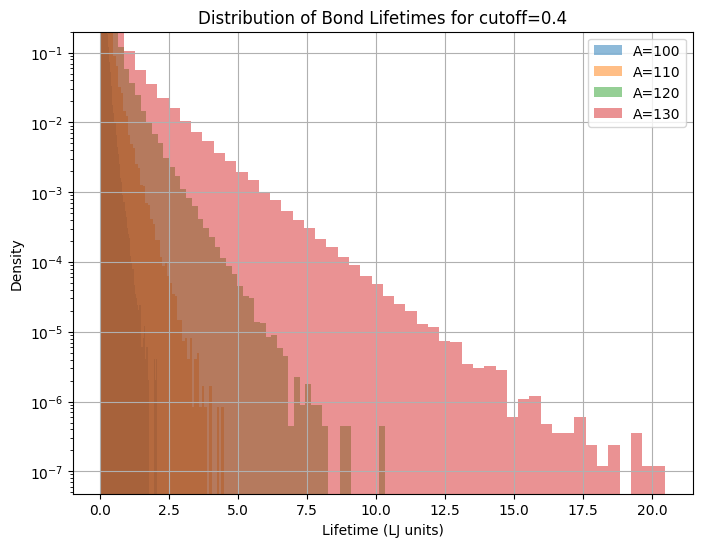

/tmp/ipykernel_752914/4004813416.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 0.2)


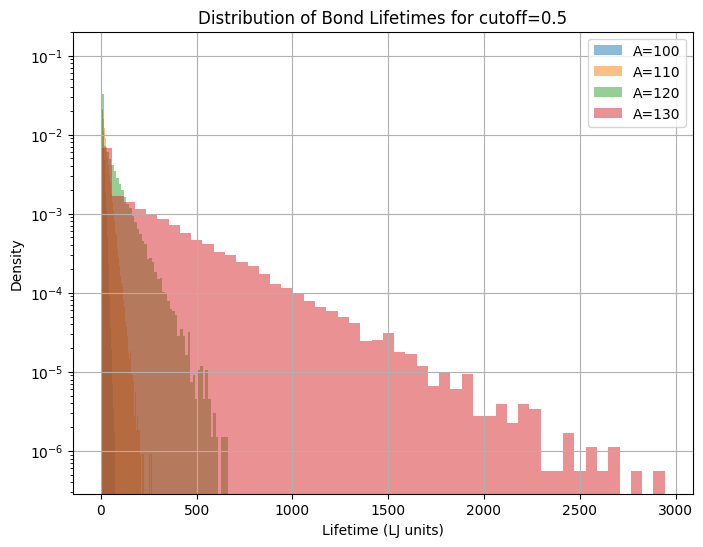

/tmp/ipykernel_752914/4004813416.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 0.2)


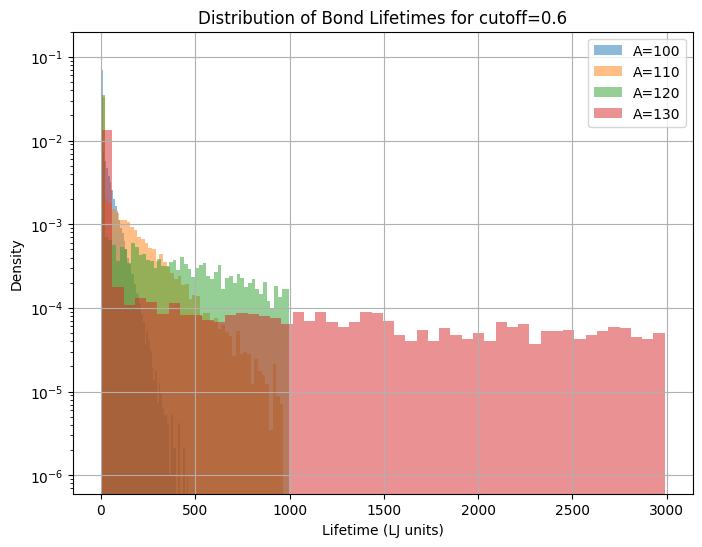

/tmp/ipykernel_752914/4004813416.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 0.2)


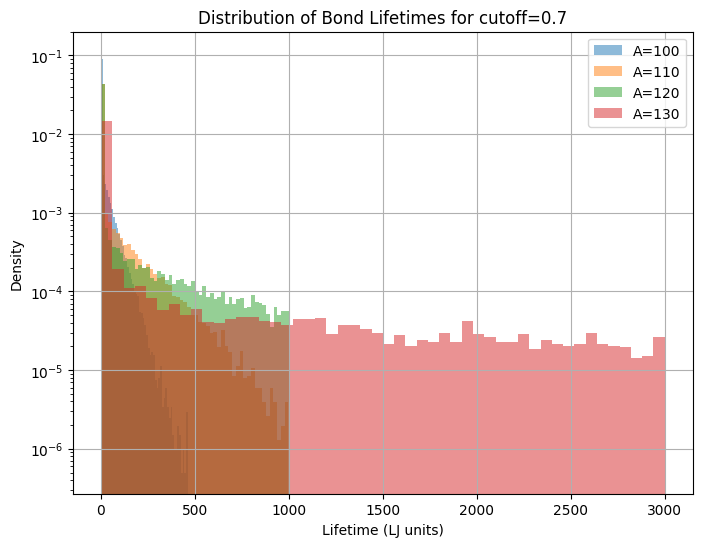

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# for cutoff in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
#     fig = plt.figure(figsize=(8, 6))
#     for A in [50, 60, 70, 80, 90, 100]:
#         df = pd.read_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff}_r0_0.25.csv")
#         lifetimes = np.array(df["lifetime"].values)
#         # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

#         values, counts = np.unique(lifetimes, return_counts=True)


#         plt.hist(values, weights=counts, bins=50, alpha=0.5, label=f"A={A}", density=True)
#     plt.xlabel("Lifetime (LJ units)")
#     plt.ylabel("Counts")
#     plt.grid()
#     plt.title(f"Distribution of Bond Lifetimes for cutoff={cutoff}")
#     plt.legend()
#     plt.show()

for cutoff in [0.4, 0.5, 0.6, 0.7]:
    fig = plt.figure(figsize=(8, 6))
    for A in [100, 110, 120, 130]:
        df = pd.read_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff}_r0_0.25.csv")
        lifetimes = np.array(df["lifetime"].values)
        # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

        values, counts = np.unique(lifetimes, return_counts=True)


        plt.hist(values, weights=counts, bins=50, alpha=0.5, label=f"A={A}", density=True)
    plt.xlabel("Lifetime (LJ units)")
    plt.ylabel("Density")
    plt.yscale("log")
    plt.ylim(0, 0.2)
    plt.grid()
    plt.title(f"Distribution of Bond Lifetimes for cutoff={cutoff}")
    plt.legend()
    plt.show()

/home/azhu13/Desktop/Work/patchy_polymers/my_env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/azhu13/Desktop/Work/patchy_polymers/my_env/lib/python3.12/site-packages/numpy/_core/_methods.py:146: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret / rcount
/home/azhu13/Desktop/Work/patchy_polymers/my_env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/azhu13/Desktop/Work/patchy_polymers/my_env/lib/python3.12/site-packages/numpy/_core/_methods.py:146: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret / rcount
/home/azhu13/Desktop/Work/patchy_polymers/my_env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/azhu13/Desktop/Work/pat

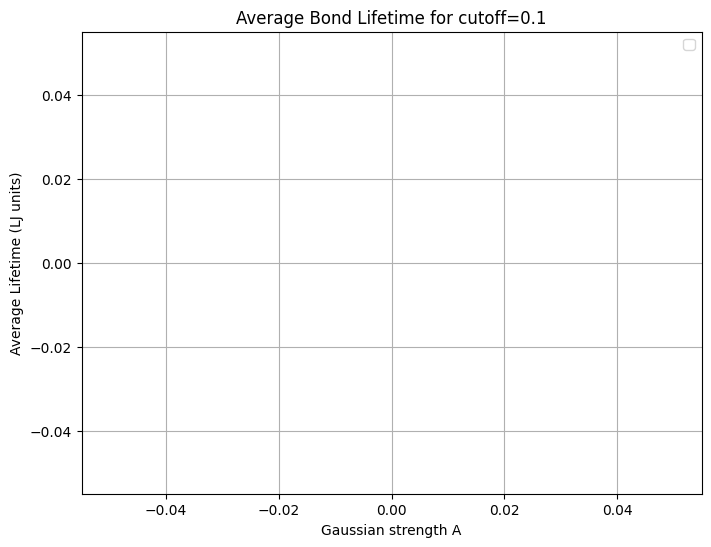

/home/azhu13/Desktop/Work/patchy_polymers/my_env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/azhu13/Desktop/Work/patchy_polymers/my_env/lib/python3.12/site-packages/numpy/_core/_methods.py:146: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret / rcount
/home/azhu13/Desktop/Work/patchy_polymers/my_env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/azhu13/Desktop/Work/patchy_polymers/my_env/lib/python3.12/site-packages/numpy/_core/_methods.py:146: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret / rcount
/home/azhu13/Desktop/Work/patchy_polymers/my_env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/azhu13/Desktop/Work/pat

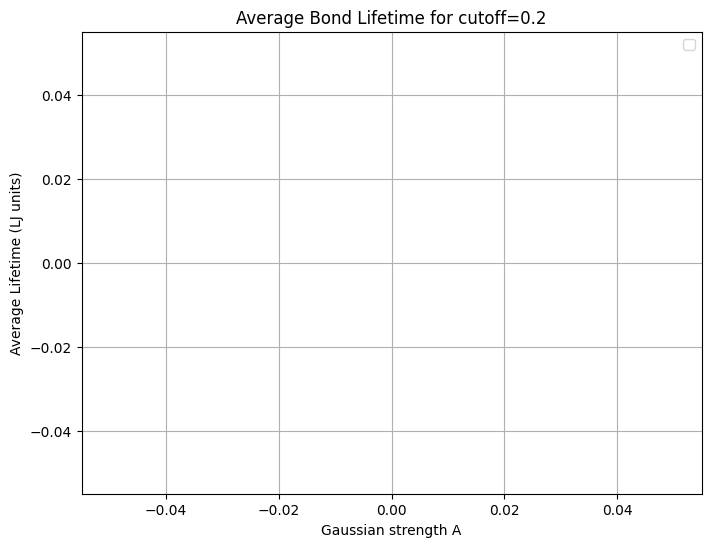

/home/azhu13/Desktop/Work/patchy_polymers/my_env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/azhu13/Desktop/Work/patchy_polymers/my_env/lib/python3.12/site-packages/numpy/_core/_methods.py:146: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret / rcount
/home/azhu13/Desktop/Work/patchy_polymers/my_env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/azhu13/Desktop/Work/patchy_polymers/my_env/lib/python3.12/site-packages/numpy/_core/_methods.py:146: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret / rcount
/tmp/ipykernel_752914/1414664146.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


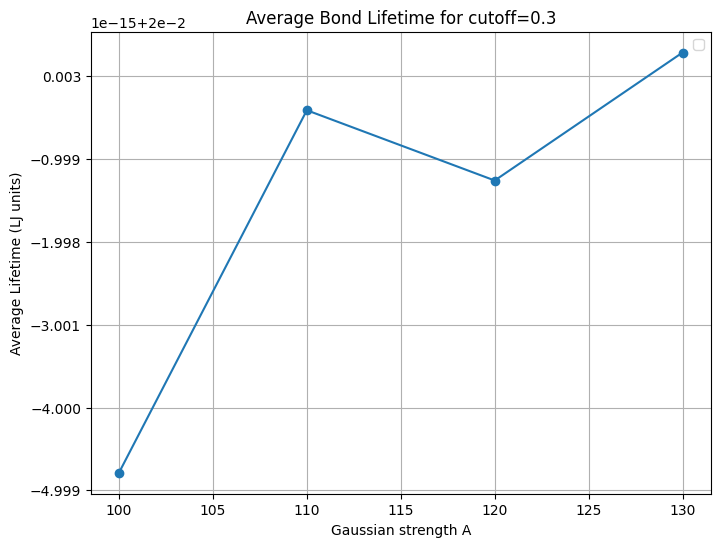

/tmp/ipykernel_752914/1414664146.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


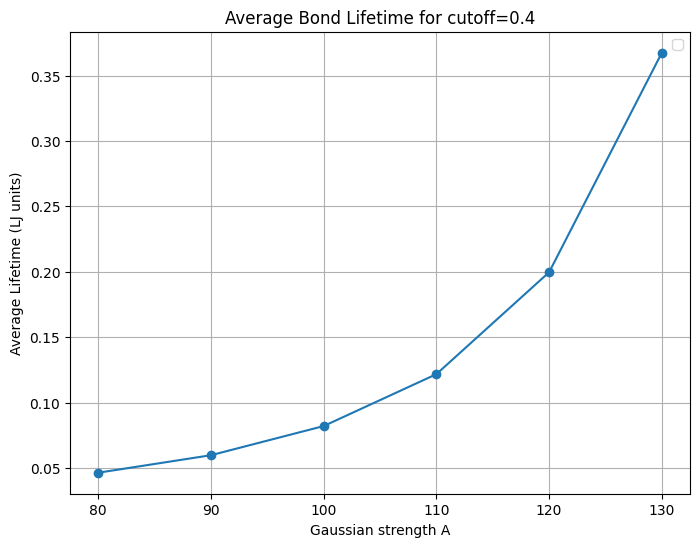

/tmp/ipykernel_752914/1414664146.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


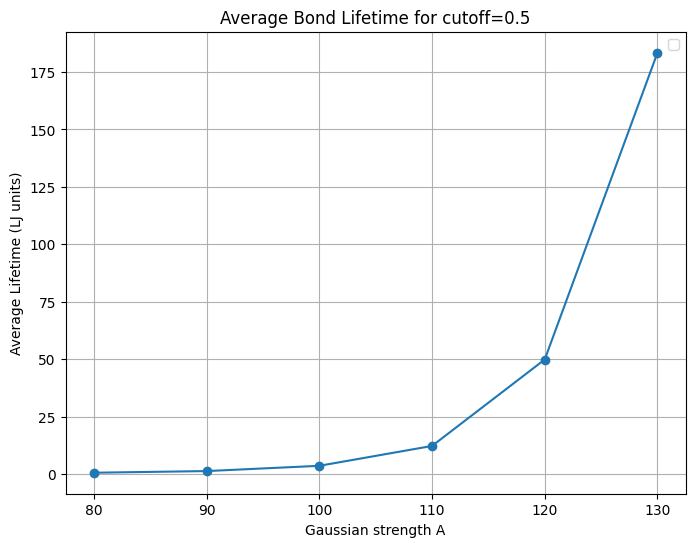

/tmp/ipykernel_752914/1414664146.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


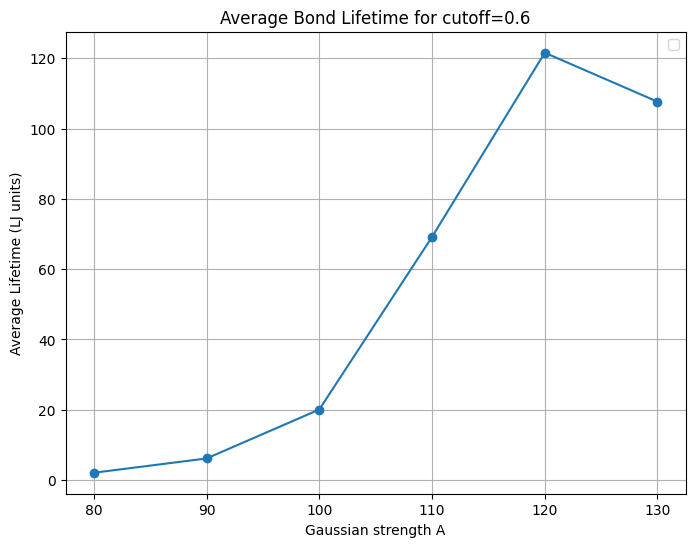

/tmp/ipykernel_752914/1414664146.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


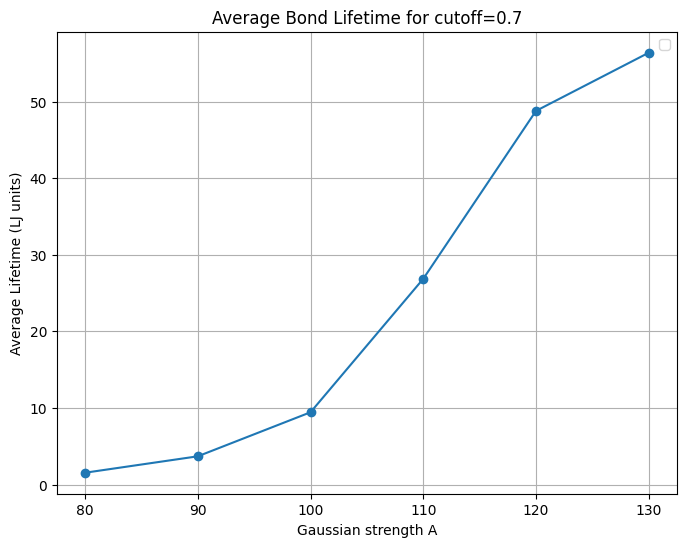

In [18]:
for cutoff in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    fig = plt.figure(figsize=(8, 6))
    average_alpha_list = []
    for A in [80, 90, 100, 110, 120, 130]:
        df = pd.read_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff}_r0_0.25.csv")
        lifetimes = np.array(df["lifetime"].values)
        # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")
        if np.mean(lifetimes) == 0:
            average_alpha_list.append(0)
        else:
            average_alpha_list.append(np.mean(lifetimes))

        
    plt.plot([80, 90, 100, 110, 120, 130], average_alpha_list, marker='o')
    plt.xlabel("Gaussian strength A")
    plt.ylabel("Average Lifetime (LJ units)")
    plt.grid()
    plt.title(f"Average Bond Lifetime for cutoff={cutoff}")
    plt.legend()
    plt.show()

In [105]:
ids_list = [np.array(lifetime[:2], dtype=int) for lifetime in lifetimes]

wrong_ids = 0
for ids in ids_list:
    if ids[0] % 35 < 31 and ids[0] % 35 != 0:
        print("Offending id:", ids[0])
        print("Per molecule id:", ids[0] % 30)
        wrong_ids += 1
    if ids[1] % 35 < 31 and ids[1] % 35 != 0:
        print("Offending id:", ids[1])
        print("Per molecule id:", ids[1] % 30)
        wrong_ids += 1

if wrong_ids:
    print(f"There are {wrong_ids} non-patch beads represented in the bonding lifetime data")

5933720
[False False False ...  True  True  True]
[ 6.  6.  6. ... 38. 34. 38.]


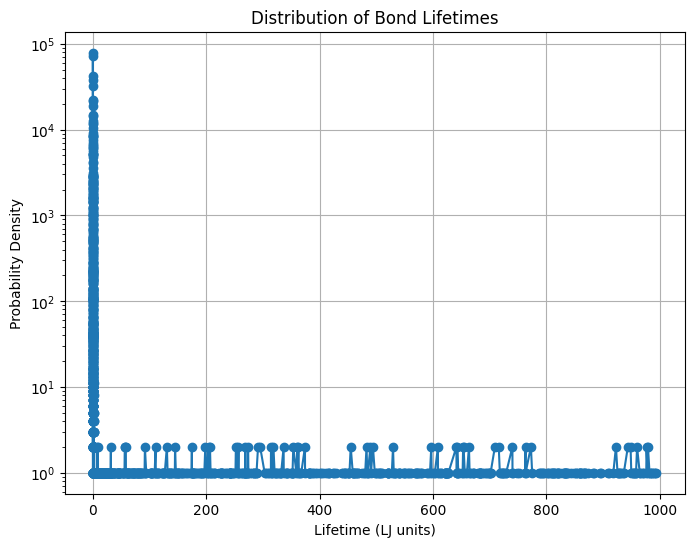

In [106]:
import sys

print(sys.getsizeof(lifetimes))
only_times = np.array([lifetime[4] for lifetime in lifetimes]) # extract only the lifetime values
print(only_times != only_times[0])
print(only_times*100)
time_counts = np.bincount((only_times).astype(int))
non_zero_counts = time_counts[time_counts > 0]
non_zero_times = np.where(time_counts > 0)[0]
# print(time_counts)
# print(sys.getsizeof(only_times))
# print(only_times[:5])
# print(len(only_times))

values, counts = np.unique(only_times, return_counts=True)

fig = plt.figure(figsize=(8, 6))
plt.semilogy(values, counts, marker='o')
plt.title("Distribution of Bond Lifetimes")
plt.xlabel("Lifetime (LJ units)")
plt.ylabel("Probability Density")
plt.grid()
plt.show()

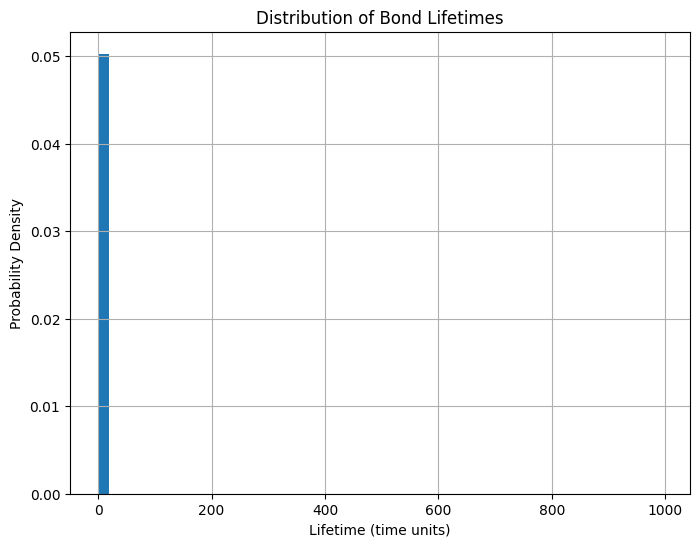

In [107]:
fig = plt.figure(figsize=(8, 6))
plt.hist(only_times, bins=50, density=True)
plt.title("Distribution of Bond Lifetimes")
plt.xlabel("Lifetime (time units)")
plt.ylabel("Probability Density")
plt.grid()
plt.show()

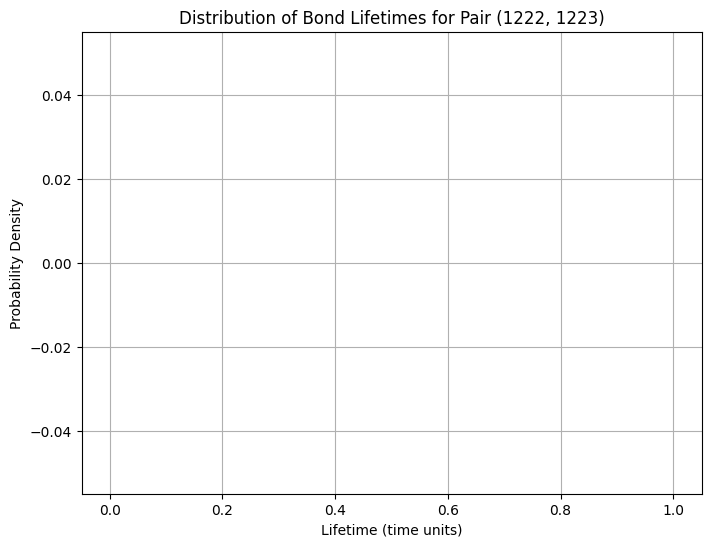

In [108]:
# examine recurring bond between a specific pair of ids
specific_id_pair = (1222, 1223)

specific_bond_lifetimes = [lifetime for lifetime in lifetimes if (lifetime[0], lifetime[1]) == specific_id_pair or (lifetime[0], lifetime[1]) == (specific_id_pair[1], specific_id_pair[0])]
fig = plt.figure(figsize=(8, 6))
plt.hist([lifetime[4] for lifetime in specific_bond_lifetimes], bins=50)
plt.title(f"Distribution of Bond Lifetimes for Pair {specific_id_pair}")
plt.xlabel("Lifetime (time units)") 
plt.ylabel("Probability Density")
plt.grid()
plt.show()


In [109]:
print("Average bond lifetime:", np.mean(only_times))

Average bond lifetime: 0.5107934431071403


## Alternative bond lifetime method (rate)

$$
N_\text{cumul}(t) = k \int_0^t N_\text{bound}(t') dt'
$$

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


"""
Process lifetimes from clustering data file. Each frame of the file contains the following sections:
- "ITEM: TIMESTEP" followed by the timestep on the next line
- "ITEM: NUMBER OF ATOMS" followed by the number of entries on the next line
- "ITEM: ATOMS" followed by the data lines for each entry, with 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster

The bonded_pairs list is a dictionary where the key is a tuple of (id1, id2) with id1 < id2 to avoid duplicates, and the value is the 
start_time of the bond. 

The bond_lifetimes list is a list of tuples (id1, id2, start_time, end_time, lifetime) for each bonded pair that has broken.

If there are any bonded_pairs that have not broken by the end of the dump, we ignore them and do not record a lifetime for them.

All times for breaking/creating are considered on the timestep we note them, so we should on average get the right time 
(i.e. both events are noted AFTER they happen)

Args:
    - filename: path to the clustering data file
Returns:
    - bond_lifetimes: list of tuples (id1, id2, start_time, end_time, lifetime) for each bonded pair
"""
def process_lifetimes(filename):
    N_cumul = {}
    N_bound = {}
    prev_timestep = None
    prev_bonds = set()  # track bonds present in previous frame to count unbinding events
    with open(filename, 'r') as f:
        time = 0
        while True:
            line = f.readline()
            if not line:
                break
            if line.startswith("ITEM: TIMESTEP"): # timestep is on next line
                time = float(f.readline().strip()) * 0.002
                print(f"Processing timestep: {time / 0.002:.0f}")
            elif line.startswith("ITEM: NUMBER OF ATOMS"): # number of entries is on next line
                N_patches = int(f.readline().strip())
            elif line.startswith("ITEM: ATOMS"): # data starts on next line
                current_bonds = set() # track current bonded pairs in this frame to compare with previous frame
                clusters = np.zeros((N_patches,7)) # 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster
                for i in range(N_patches):
                    clusters[i] = np.array(f.readline().strip().split(), dtype=float)
                # filter only consider bonds with at least 1 patch
                clusters = clusters[clusters[:,5] > 0] # patch_coord is in column 5
                # sort by patch_cluster (get bonded pairs) 
                clusters = clusters[clusters[:,6].argsort()] # patch_cluster is in column 6
                for i in range(len(clusters)-1):
                    id1, id2 = int(clusters[i][0]), int(clusters[i+1][0]) # get ids of current and next cluster
                    if clusters[i][6] == clusters[i+1][6]: # if same patch_cluster, they are bonded
                        ids = (id1, id2) if id1 < id2 else (id2, id1) # order ids to avoid duplicates
                        current_bonds.add(ids) # add to current bonds set
                
                # instantaneous number of bound pairs at this timestep
                N_bound[time] = len(current_bonds)

                # count number of unbinding (finished) events at this timestep: bonds present previously but gone now
                num_unbound = len(prev_bonds - current_bonds)
                if prev_timestep is None:
                    N_cumul[time] = num_unbound
                else:
                    N_cumul[time] = N_cumul[prev_timestep] + num_unbound

                # update trackers for next frame
                prev_bonds = current_bonds.copy()
                prev_timestep = time
    return N_bound, N_cumul




In [30]:
f = "data/patches/0.7prodpatch_chainlength_30_patchspacing_5_N_beads_24000_gaussA_45_r0_0.35_gaussB_10_seed_12345.bin.txt"
N_bound, N_cumul = process_lifetimes(f)

Processing timestep: 3000000
Processing timestep: 3000010
Processing timestep: 3000020
Processing timestep: 3000030
Processing timestep: 3000040
Processing timestep: 3000050
Processing timestep: 3000060
Processing timestep: 3000070
Processing timestep: 3000080
Processing timestep: 3000090
Processing timestep: 3000100
Processing timestep: 3000110
Processing timestep: 3000120
Processing timestep: 3000130
Processing timestep: 3000140
Processing timestep: 3000150
Processing timestep: 3000160
Processing timestep: 3000170
Processing timestep: 3000180
Processing timestep: 3000190
Processing timestep: 3000200
Processing timestep: 3000210
Processing timestep: 3000220
Processing timestep: 3000230
Processing timestep: 3000240
Processing timestep: 3000250
Processing timestep: 3000260
Processing timestep: 3000270
Processing timestep: 3000280
Processing timestep: 3000290
Processing timestep: 3000300
Processing timestep: 3000310
Processing timestep: 3000320
Processing timestep: 3000330
Processing tim

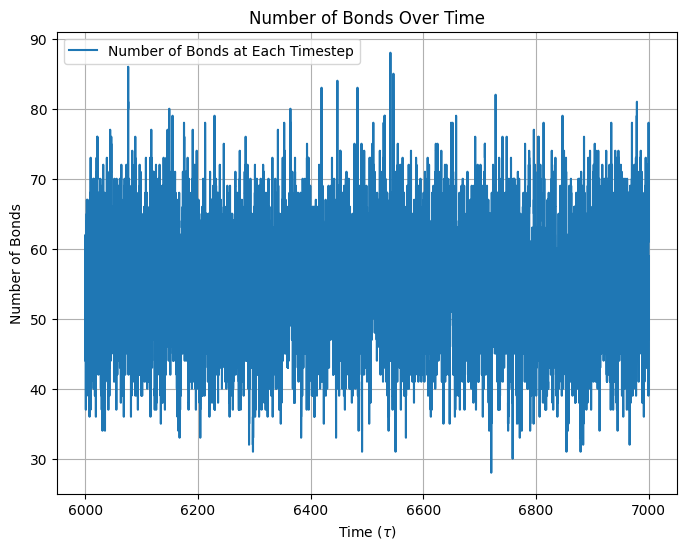

In [31]:
fig = plt.figure(figsize=(8, 6))
start = 0
plt.plot(np.array(list(N_bound.keys()))[start:], np.array(list(N_bound.values())[start:]), label="Number of Bonds at Each Timestep")
# plt.plot(np.array(list(N_cumul.keys()))[start:] * 0.005, list(N_cumul.values())[start:], label="Cumulative Number of Bonds Formed")
plt.title("Number of Bonds Over Time")
plt.xlabel(r"Time ($\tau$)")
plt.ylabel("Number of Bonds")
plt.grid()
plt.legend()
plt.show()

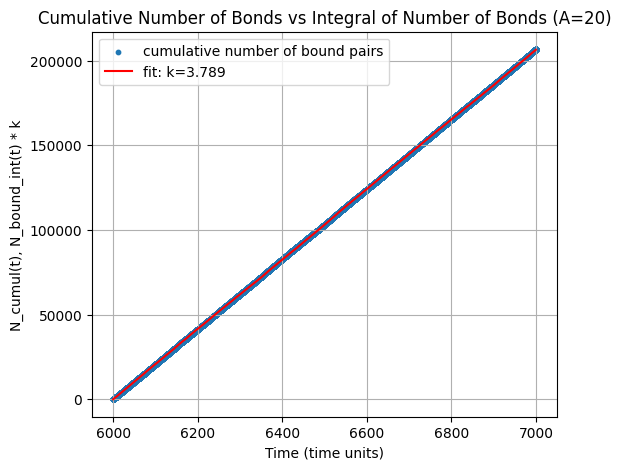

k = 3.7894515304031713


In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Fit N_cumul_list = k * N_bound_int + b (add bias term)
# Use the 'start' index defined earlier to select a tail portion
# Build arrays of times (in time units), N_bound values and N_cumul values
times = np.array(list(N_bound.keys())[start:], dtype=float)
n_b = np.array(list(N_bound.values())[start:], dtype=float)
n_c = np.array(list(N_cumul.values())[start:], dtype=float)

# Compute trapezoidal integral X(t) = \int_0^t N_bound dt (time units)
dt = np.diff(times)
segments = 0.5 * (n_b[1:] + n_b[:-1]) * dt
X = np.concatenate(([0.0], np.cumsum(segments)))

# Perform linear least-squares to get slope (k) and intercept (b): n_c = k * X + b
# A = np.vstack([X, np.ones_like(X)]).T
# k, b = np.linalg.lstsq(A, n_c, rcond=None)[0]   
k = X @ n_c / (X @ X) 

# Plot data and fit
plt.figure(figsize=(6,5))
plt.scatter(times, n_c, label='cumulative number of bound pairs', s=10)
# plt.plot(times, X, label="cumulative number of bound ")
plt.plot(times, k * X, label=f'fit: k={k:.4g}', color='red')
plt.title("Cumulative Number of Bonds vs Integral of Number of Bonds (A=20)")
plt.xlabel('Time (time units)')
plt.ylabel('N_cumul(t), N_bound_int(t) * k')
plt.grid(True)
plt.legend()
plt.show()

print(f"k = {k}")
